# Finding Outliers in PCA Plot

This notebook loads the PCA results and identifies outliers based on distance from the center of the PCA space.

In [1]:
import numpy as np
import json
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import os

In [2]:
# Specify path to PCA output
os.chdir(Path.cwd().parent)
pca_output_root = Path("analysis/temporaryPCA1000Files") # CHANGE THIS TO PATH TO PCA OUTPUT

print(f"Files found: at {pca_output_root}:")
for f in pca_output_root.glob("*"):
    print(f"-{f.name}")

Files found: at analysis/temporaryPCA1000Files:
-pca_results.npz
-window_index.npz
-pca_plot.png
-pca_meta.json


In [3]:
# Load PCA data
pca_data = np.load(pca_output_root / "pca_results.npz", allow_pickle=True)
X_pca = pca_data["X_pca"]
X_raw = pca_data["X_raw"] # raw data
evr = pca_data["evr"] # explained variance ratio

print(f"X_pca shape: {X_pca.shape}") # should have shape (n_samples, n_components)
print(f"X_raw shape: {X_raw.shape}") # should have shape (n_samples, n_mels)

X_pca shape: (52470, 20)
X_raw shape: (52470, 104)


In [4]:
# Load window metadata
window_data = np.load(pca_output_root / "window_index.npz", allow_pickle=True)
files = window_data["files"]
start_frames = window_data["start_frames"]
start_secs = window_data["start_secs"]

print(f"{len(files)} windows")
print(f"for example: {files[:5]}")

52470 windows
for example: ['6229.220802162000.npz' '6229.220802162000.npz' '6229.220802162000.npz'
 '6229.220802162000.npz' '6229.220802162000.npz']


In [5]:
# Load metadata
with open(pca_output_root / "pca_meta.json") as f:
    meta = json.load(f)

print(f"PCA analysis metadata:")
print(f"  Created: {meta['created']}")
print(f"  Total windows: {meta['n_windows']}")
print(f"  n Components: {meta['n_components']}")
print(f"  Files in root: {len(meta['files'])}")


PCA analysis metadata:
  Created: 2026-03-18T17:13:37.066343
  Total windows: 52470
  n Components: 20
  Files in root: 990


In [6]:
# Calculate distance from center in PCA space
# Alternatively try using Mahalanobis afstand

# Euclidean distance from mean
mean_pca = X_pca.mean(axis=0)
distances_euclidean = np.sqrt(np.sum((X_pca - mean_pca) ** 2, axis=1))

# Mahalanobis distance from mean
cov_pca = np.cov(X_pca, rowvar=False) # rowvar to correct for samples in rows
inv_cov = np.linalg.inv(cov_pca)


distances_mahal = [np.sqrt((X_pca[i] - mean_pca).T @ inv_cov @ (X_pca[i] - mean_pca)) for i in range(X_pca.shape[0])]
distances_mahal = np.array(distances_mahal)


print(f"Euclidean distance stats:")
print(f"  Mean: {distances_euclidean.mean():.3f}, Std: {distances_euclidean.std():.3f}")
print(f"  Min: {distances_euclidean.min():.3f}, Max: {distances_euclidean.max():.3f}")
print(f"\nMahalanobis distance stats:")
print(f"  Mean: {distances_mahal.mean():.3f}, Std: {distances_mahal.std():.3f}")
print(f"  Min: {distances_mahal.min():.3f}, Max: {distances_mahal.max():.3f}")

Euclidean distance stats:
  Mean: 28.440, Std: 17.570
  Min: 2.048, Max: 156.614

Mahalanobis distance stats:
  Mean: 4.250, Std: 1.392
  Min: 1.405, Max: 37.081


In [7]:
# Define outliers and make mask
distances = distances_euclidean
threshold = distances.mean() + 3 * distances.std() # outlier defined as more than 3 std dev from mean
outlier_mask = distances > threshold
outlier_indices = np.where(outlier_mask)[0]

print(f"Threshold: {threshold:.3f}")
print(f"Number of outliers: {len(outlier_indices)} out of {len(distances)} windows")

Threshold: 81.150
Number of outliers: 596 out of 52470 windows


In [8]:
# Create detailed table of outliers with source information
outlier_info = []

for idx in outlier_indices:
    outlier_info.append({
        "Index": idx,
        "File": files[idx],
        "Start Frame": int(start_frames[idx]),
        "Start Time (s)": float(start_secs[idx]),
        "Distance": distances[idx],
        "PC1": X_pca[idx, 0],
        "PC2": X_pca[idx, 1] if X_pca.shape[1] > 1 else 0,
    })

outlier_df = pd.DataFrame(outlier_info)
outlier_df = outlier_df.sort_values("Distance", ascending=False)

print(outlier_df.to_string())

     Index                   File  Start Frame  Start Time (s)    Distance         PC1        PC2
461  25361  6229.220816204000.npz        16875           135.0  156.614426 -154.095428  20.836529
473  25787  6229.220817040000.npz        18125           145.0  156.263962 -154.293243  17.685514
474  25788  6229.220817040000.npz        18750           150.0  153.110962 -151.448868  15.058255
462  25362  6229.220816204000.npz        17500           140.0  146.092148 -144.073242  17.176683
463  25363  6229.220816204000.npz        18125           145.0  141.235901 -139.213028  16.970560
460  25360  6229.220816204000.npz        16250           130.0  139.190979 -136.214905  19.975754
459  25359  6229.220816204000.npz        15625           125.0  131.749405 -127.604042  25.564507
458  25358  6229.220816204000.npz        15000           120.0  130.934509 -126.237976  27.011147
472  25786  6229.220817040000.npz        17500           140.0  127.825699 -125.177635  19.867237
464  25364  6229.220

In [9]:
# Group outliers by source file
outliers_by_file_grouped = outlier_df.groupby("File").size().sort_values(ascending=False)
outliers_by_file = outlier_df.sort_values("File", ascending=False)
print(outliers_by_file_grouped.to_string())
print(outliers_by_file.to_string())

File
6229.220802162000.npz    53
6229.220813012000.npz    53
6229.220812100000.npz    53
6229.220813014000.npz    53
6229.220809200000.npz    53
6229.220802164000.npz    46
6229.220809202000.npz    28
6229.220812094000.npz    22
6229.220818034000.npz    12
6229.220816204000.npz    12
6229.220817040000.npz    11
6229.220808174000.npz    11
6229.220812092000.npz     9
6229.220812080000.npz     7
6229.220812090000.npz     5
6229.220816160000.npz     4
6229.220815134000.npz     2
6229.220822060000.npz     2
6229.220827012000.npz     2
6229.220806184000.npz     2
6229.220829052000.npz     1
6229.220831160000.npz     1
6229.220831200000.npz     1
6229.220824234000.npz     1
6229.220825042000.npz     1
6229.220825044000.npz     1
6229.220831162000.npz     1
6229.220825152000.npz     1
6229.220831144000.npz     1
6229.220824174000.npz     1
6229.220825154000.npz     1
6229.220825160000.npz     1
6229.220831044000.npz     1
6229.220825220000.npz     1
6229.220825232000.npz     1
6229.2208252340

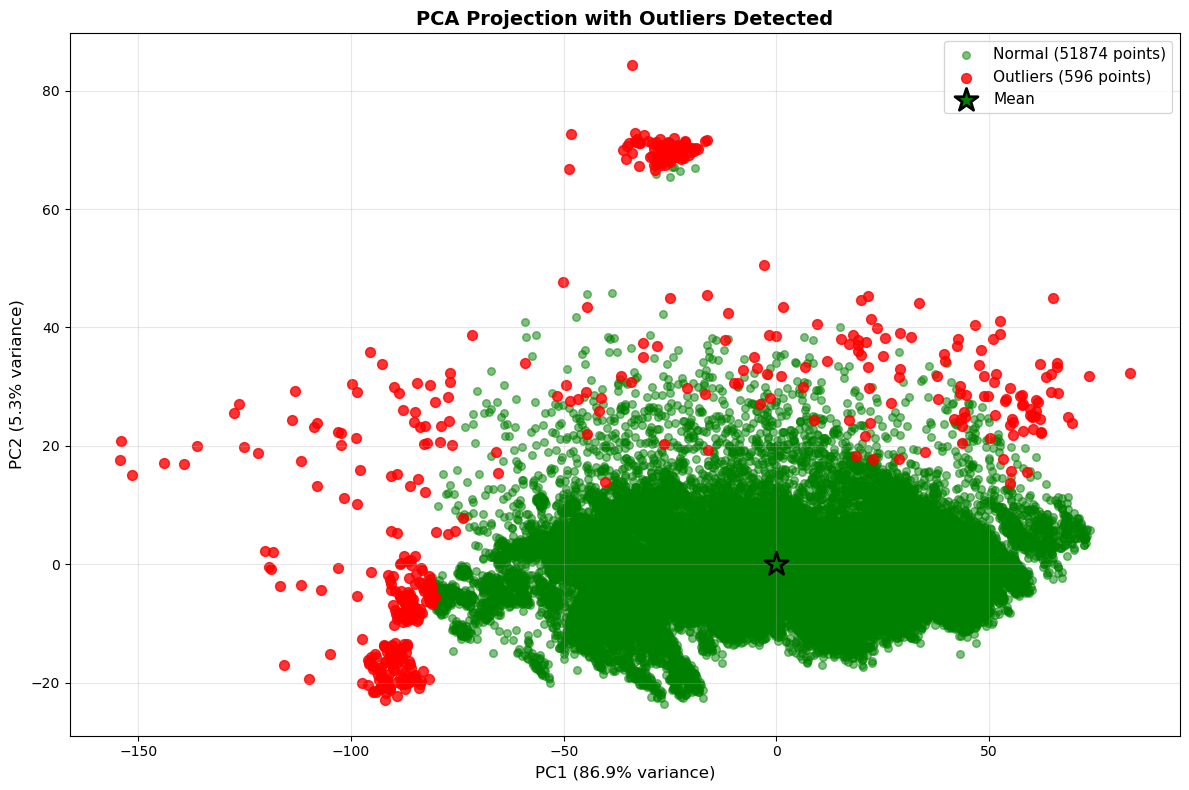

In [10]:
# Visualize PCA plot with outliers highlighted
assert X_pca.shape[1] >= 2, "minimum 2 PCA components for plotting"
fig, ax = plt.subplots(figsize=(12, 8))

# Plot normal points
normal_mask = ~outlier_mask
normal_x = X_pca[normal_mask, 0]
normal_y = X_pca[normal_mask, 1]
ax.scatter(normal_x, normal_y, 
            c='green', alpha=0.5, s=30, label=f'Normal ({normal_mask.sum()} points)')

# Plot outliers
outlier_x = X_pca[outlier_mask, 0]
outlier_y = X_pca[outlier_mask, 1]
ax.scatter(outlier_x, outlier_y, 
            c='red', alpha=0.8, s=50, label=f'Outliers ({outlier_mask.sum()} points)')

# Plot center
ax.scatter(mean_pca[0], mean_pca[1], c='green', s=300, 
            marker='*', label='Mean', zorder=5, edgecolors='black', linewidths=2)

ax.set_xlabel(f'PC1 ({evr[0]*100:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({evr[1]*100:.1f}% variance)', fontsize=12)
ax.set_title('PCA Projection with Outliers Detected', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
#out_plot = pca_output_root / "outliers_pca_plot.png"
#plt.savefig(out_plot, dpi=150, bbox_inches='tight')
plt.show()

#print(f"\nPlot saved to: {out_plot}")


In [ ]:
# Save outlier summary to CSV
csv_path = pca_output_root / "outliers_summary.csv"
outlier_df.to_csv(csv_path, index=False)
print(f"Outlier summary saved to: {csv_path}")
print(f"Total outliers: {len(outlier_df)}")

Outlier summary saved to: analysis/pca_output/testrun/outliers_summary.csv

Total outliers extracted: 2
